In [3]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op

dwi_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/dwi_forAnnasCP'

In [50]:
connectome = pd.read_csv(op.join(dwi_folder,'sub-04/processing/connectome/AAL3_amended/connectome.csv'),header=None)
connectome.shape

(170, 170)

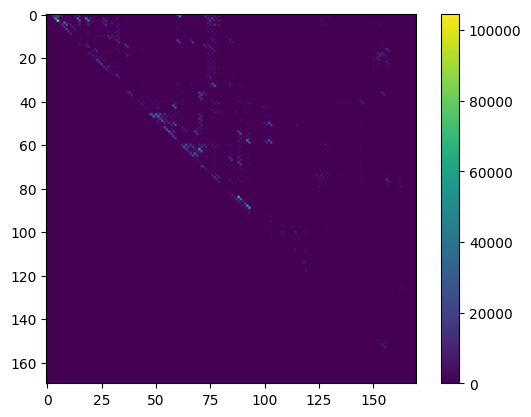

In [51]:
plt.imshow(connectome)
plt.colorbar()


[(0.0, 1e-06)]

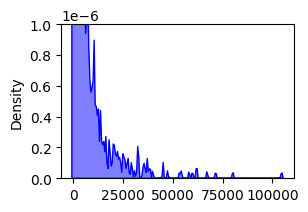

In [52]:
fig,ax = plt.subplots(figsize=(3,2))
sns.kdeplot(connectome.values.flatten(),fill=True, color='blue', alpha=0.5,ax=ax)
ax.set(ylim=(0, 0.000001))


<Axes: >

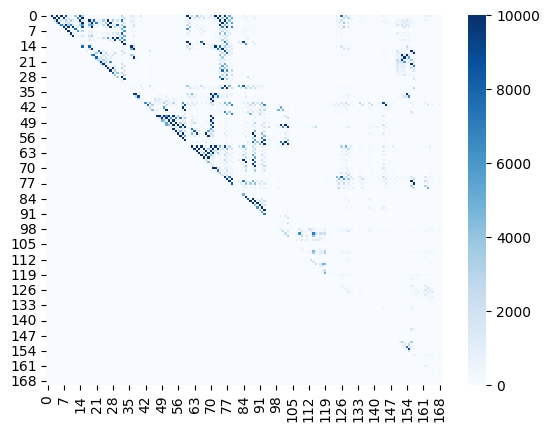

In [53]:
sns.heatmap(connectome,  vmin=0, vmax=10000,cmap='Blues')

<Axes: ylabel='Density'>

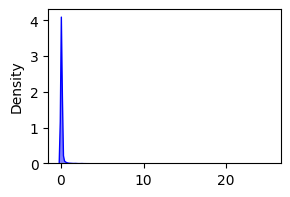

In [55]:
# Scale correctly
mu_factor = pd.read_table(op.join(dwi_folder,'sub-04/processing/tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]
C = np.array(connectome)

C_scaled = (C + C.T) * mu_factor

fig,ax = plt.subplots(figsize=(3,2))
sns.kdeplot(C_scaled.flatten(),fill=True, color='blue', alpha=0.5,ax=ax)
#ax.set(ylim=(0, 0.000001))


<Axes: >

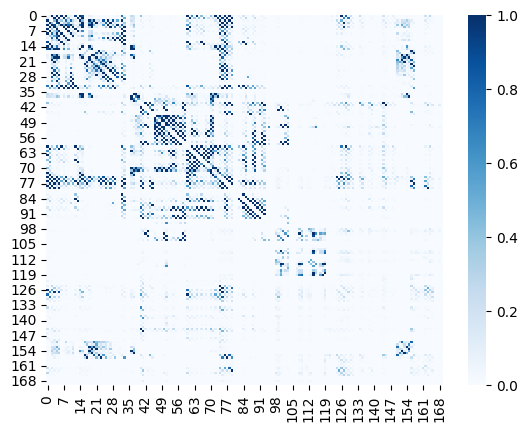

In [58]:
sns.heatmap(C_scaled,  vmin=0, vmax=1,cmap='Blues')

In [73]:
# Atlas Annotations

atlas_names = pd.read_table('/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/AAL3/amended/WRONG_aal3_amended_draft.txt',
                          skiprows=15,header=None, delim_whitespace=True,
                          usecols = [0,1,2])
atlas_names.columns = ['parcel_N','label_abrv','label']                          
atlas_names

/tmp/ipykernel_3248758/387983191.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  atlas_names = pd.read_table('/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/AAL3/amended/WRONG_aal3_amended_draft.txt',


,parcel_N,label_abrv,label
0,0,???,Unknown
1,1,FAL,Precentral_L
2,2,FAR,Precentral_R
3,3,F1_2L,Frontal_Sup_2_L
4,4,F1_2R,Frontal_Sup_2_R
...,...,...,...
145,tPuAL,Thal_PuA_L,147
146,tPuAR,Thal_PuA_R,148
147,tPuLL,Thal_PuL_L,149
148,tPuLR,Thal_PuL_R,150


In [64]:
atlas_name

,4,F1_2R,Frontal_Sup_2_R,212,91,65,255
0,5,F2_2L,Frontal_Mid_2_L,157,179,83.0,255.0
1,6,F2_2R,Frontal_Mid_2_R,157,179,83.0,255.0
2,7,F3OPL,Frontal_Inf_Oper_L,192,207,213.0,255.0
3,8,F3OPR,Frontal_Inf_Oper_R,192,207,213.0,255.0
4,9,F3TL,Frontal_Inf_Tri_L,220,245,129.0,255.0
...,...,...,...,...,...,...,...
140,tPuAL,Thal_PuA_L,147,266,266,NaN,NaN
141,tPuAR,Thal_PuA_R,148,274,274,NaN,NaN
142,tPuLL,Thal_PuL_L,149,214,214,NaN,NaN
143,tPuLR,Thal_PuL_R,150,200,200,NaN,NaN
